In [4]:
import sys
sys.path.insert(0, '.')
sys.path.insert(1, '..')
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit
from utils import *

In [5]:
preds_dir = '/home/bela/thesis/preds_DDIM/'
dataset_dir = '../../data/all_years_merged_era5.nc'
dataset_dir2 = '../../data/era5_3h_merged.nc'
preds_dir2 = '/home/bela/thesis/preds_DDIM_3h/'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)
years2 = [i for i in range(1984, 2024)]


[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [6]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [7]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)
eval_split2, ground_truth_wind_speeds2, scale2 = get_ground_truth_ws(data_dir=dataset_dir2,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)

In [8]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

def downsampling(xarray, factor):
    return xarray.isel(latitude=slice(0, None, factor), longitude=slice(0, None, factor))
lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)

def get_low_res_ws2(test_data, scaling_factor):
    u10 = downsampling(test_data['u10'], scaling_factor).values
    v10 = downsampling(test_data['v10'], scaling_factor).values
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws
lr_wind_speeds2 = get_low_res_ws2(eval_split2, SCALING_FACTOR)

In [9]:
#preds_DDIM_1984_4.pt

In [10]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        
        
        
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False, map_location=torch.device('cpu'))
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            print(baseline.shape)
            
        elif file == f'preds_DDIM_{year}_{scaling_factor}.pt':
            field = torch.load(files_dir + file, weights_only=False, map_location=torch.device('cpu'))
            field = field.squeeze(1)
            
            names.append("DDIM")
            ws_field = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(ws_field)
            print(ws_field.shape)
    return ws_fields, names


In [11]:
longitudes = eval_split2.longitude.values[:32]
latitudes = eval_split2.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


In [12]:
ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)

ws_fields2, names2 = get_wind_speed_fields(files_dir=preds_dir2,
                                        scaling_factor=SCALING_FACTOR,
                                        year=TEST_YEAR,
                                        normalization_scale=scale2,
                                        lr_ws=lr_wind_speeds2,
                                        gt_ws=ground_truth_wind_speeds2)

torch.Size([1458, 32, 32])
torch.Size([1464, 32, 32])
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])


In [13]:
ddim = ws_fields[names.index("DDIM")]
hr_gt = ws_fields[names.index("HR Ground Truth")]  

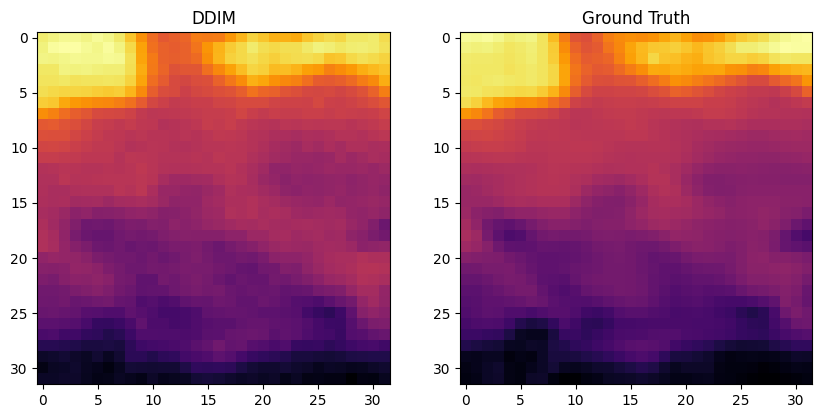

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ddim[0], cmap='inferno')
ax[0].set_title("DDIM")
ax[1].imshow(hr_gt[0], cmap='inferno')
ax[1].set_title("Ground Truth")
plt.show()

In [15]:

hr_gt = hr_gt[1:-5]
print(len(hr_gt), len(ddim))

1458 1458


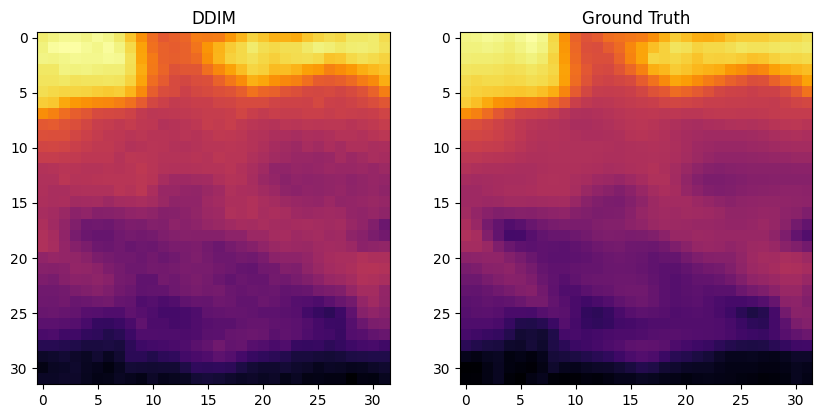

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ddim[0], cmap='inferno')
ax[0].set_title("DDIM")
ax[1].imshow(hr_gt[0], cmap='inferno')
ax[1].set_title("Ground Truth")
plt.show()


2928 2928


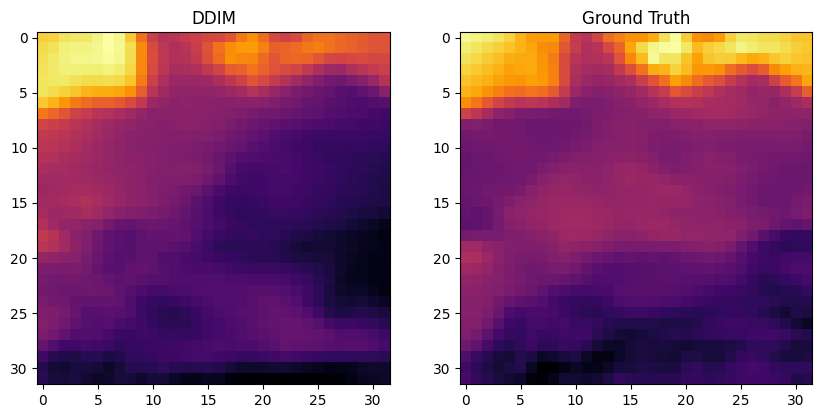

In [17]:
hr_gt2 = ws_fields2[names2.index("HR Ground Truth")]
ddim2 = ws_fields2[names2.index("DDIM")]
print(len(hr_gt2), len(ddim2))
#plot first image of both
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ddim2[-101], cmap='inferno')
ax[0].set_title("DDIM")
ax[1].imshow(hr_gt2[-111], cmap='inferno')
ax[1].set_title("Ground Truth")
plt.show()


464


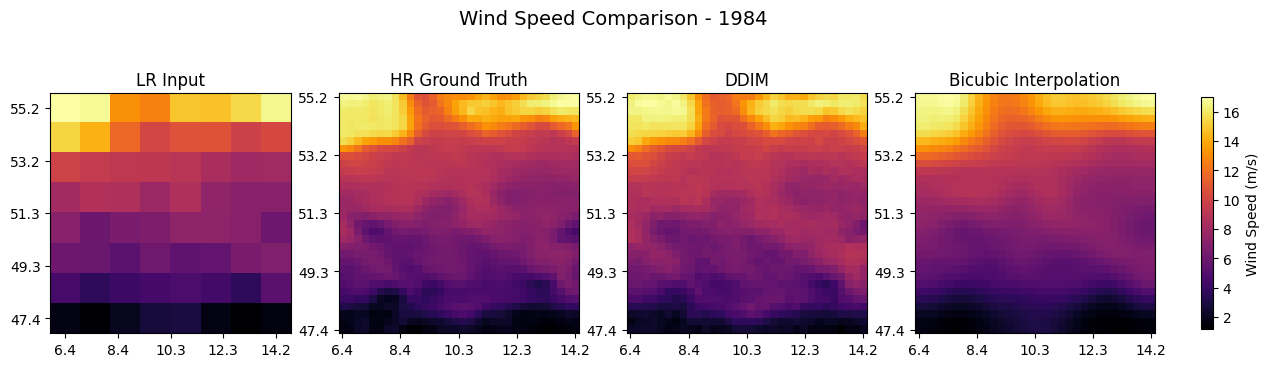

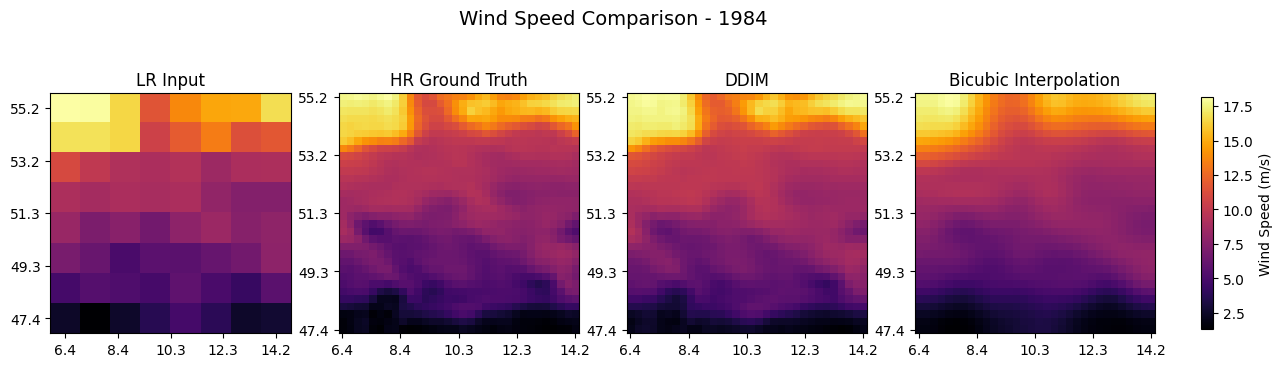

In [18]:
def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 8))
    fields = [field[index] for field in fields]
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        ax[i].set_title(names[i])
        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks])
        ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks])
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    plt.suptitle(f"Wind Speed Comparison - {TEST_YEAR}", fontsize=14, y=.75)
    plt.show()



index = np.random.randint(0, len(ground_truth_wind_speeds))
index2 = np.random.randint(0, len(ground_truth_wind_speeds2)-11)
print(index)
plot_comparison(ws_fields, names, 0)
plot_comparison(ws_fields2, names2, 1)

In [19]:
print(len(ground_truth_wind_speeds2))

2928


In [20]:

ws_dict = {year: {} for year in years}
for year in years:
        print(f"Processing year {year}")
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr = ws_fields[names.index('DDIM')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        ws_dict[year]['DDIM'] = edsr
        ws_dict[year]['Baseline'] = baseline
        ws_dict[year]['Ground Truth'] = ground_truth_wind_speeds



Processing year 1984
torch.Size([1458, 32, 32])
torch.Size([1464, 32, 32])
Processing year 1985
torch.Size([1454, 32, 32])
torch.Size([1460, 32, 32])
Processing year 1986
torch.Size([1454, 32, 32])
torch.Size([1460, 32, 32])
Processing year 1987
torch.Size([1460, 32, 32])
torch.Size([1454, 32, 32])
Processing year 1988
torch.Size([1458, 32, 32])
torch.Size([1464, 32, 32])
Processing year 1989
torch.Size([1454, 32, 32])
torch.Size([1460, 32, 32])
Processing year 1990
torch.Size([1454, 32, 32])
torch.Size([1460, 32, 32])
Processing year 1991
torch.Size([1460, 32, 32])
torch.Size([1454, 32, 32])
Processing year 1992
torch.Size([1458, 32, 32])
torch.Size([1464, 32, 32])
Processing year 1993
torch.Size([1460, 32, 32])
torch.Size([1454, 32, 32])
Processing year 1994
torch.Size([1454, 32, 32])
torch.Size([1460, 32, 32])
Processing year 1995
torch.Size([1460, 32, 32])
torch.Size([1454, 32, 32])
Processing year 1996
torch.Size([1464, 32, 32])
torch.Size([1458, 32, 32])
Processing year 1997
torc

In [21]:
ws_dict2 = {year: {} for year in years2}

for year in years2:
        print(f"Processing year {year}")    
        eval_split2, ground_truth_wind_speeds2, scale2 = get_ground_truth_ws(data_dir=dataset_dir2,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        lr_wind_speeds2 = get_low_res_ws2(eval_split2, SCALING_FACTOR)
        ws_fields2, names2 = get_wind_speed_fields(files_dir=preds_dir2, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale2, 
                                                lr_ws=lr_wind_speeds2, 
                                                gt_ws=ground_truth_wind_speeds2)
        ddim = ws_fields2[names2.index('DDIM')]
        baseline = ws_fields2[names2.index('Bicubic Interpolation')]
        ws_dict2[year]['DDIM'] = ddim
        ws_dict2[year]['Baseline'] = baseline
        ws_dict2[year]['Ground Truth'] = ground_truth_wind_speeds2
        

Processing year 1984
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1985
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1986
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1987
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1988
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1989
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1990
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1991
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1992
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1993
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1994
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1995
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1996
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1997
torc

In [ ]:
def get_metrics_over_time(years):
    mses = {'DDIM': [], 'Bicubic': []}
    maes = {'DDIM': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        edsr, baseline = ws_dict2[year]['DDIM'], ws_dict2[year]['Baseline']
        ground_truth_wind_speeds = ws_dict2[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['DDIM'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['DDIM'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    
    for i, model in enumerate(mses):
        # Plot MSE for the current model
        ax[i, 0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color='blue')
        ax[i, 0].set_title(f'{model} - MSE')
        ax[i, 0].set_xlabel('Year')
        ax[i, 0].set_ylabel('MSE')
        ax[i, 0].legend()
        ax[i, 0].grid(True)

        # Plot MAE for the current model
        ax[i, 1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color='orange')
        ax[i, 1].set_title(f'{model} - MAE')
        ax[i, 1].set_xlabel('Year')
        ax[i, 1].set_ylabel('MAE')
        ax[i, 1].legend()
        ax[i, 1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score', color='blue')
    ax[0].set_title('MSE Skill Score')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score', color='orange')
    ax[1].set_title('MAE Skill Score')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    

In [23]:
mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

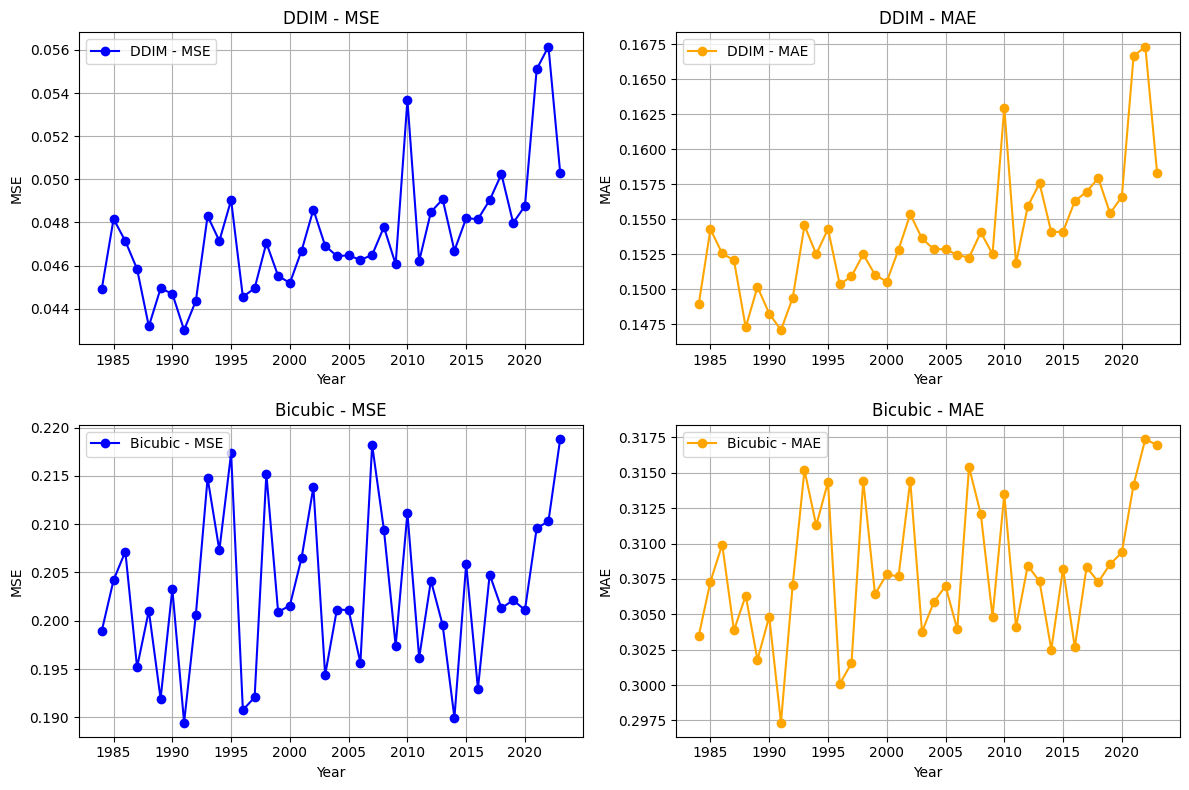

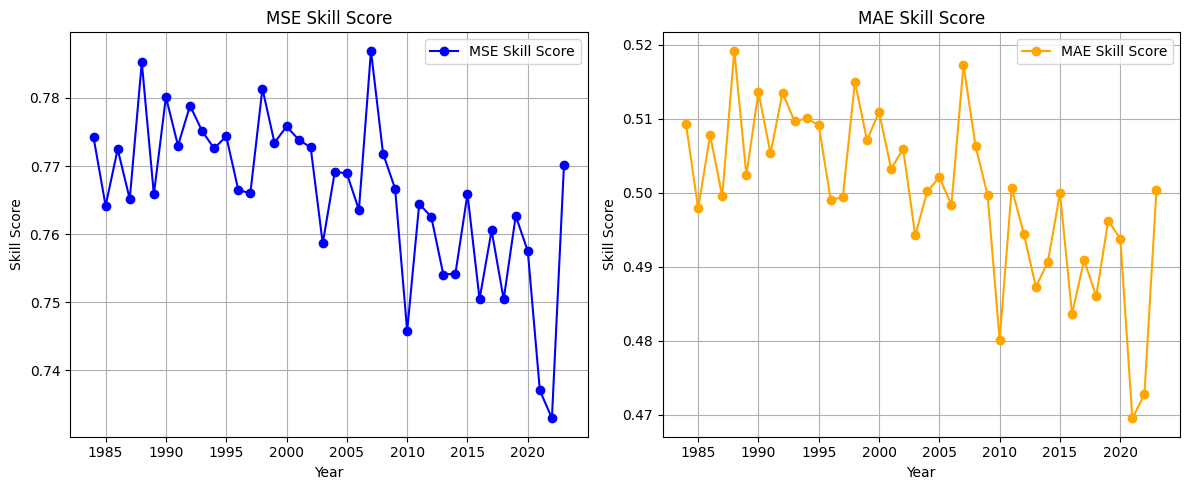

In [24]:
plot_metrics_over_time(years, mses, maes)
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)

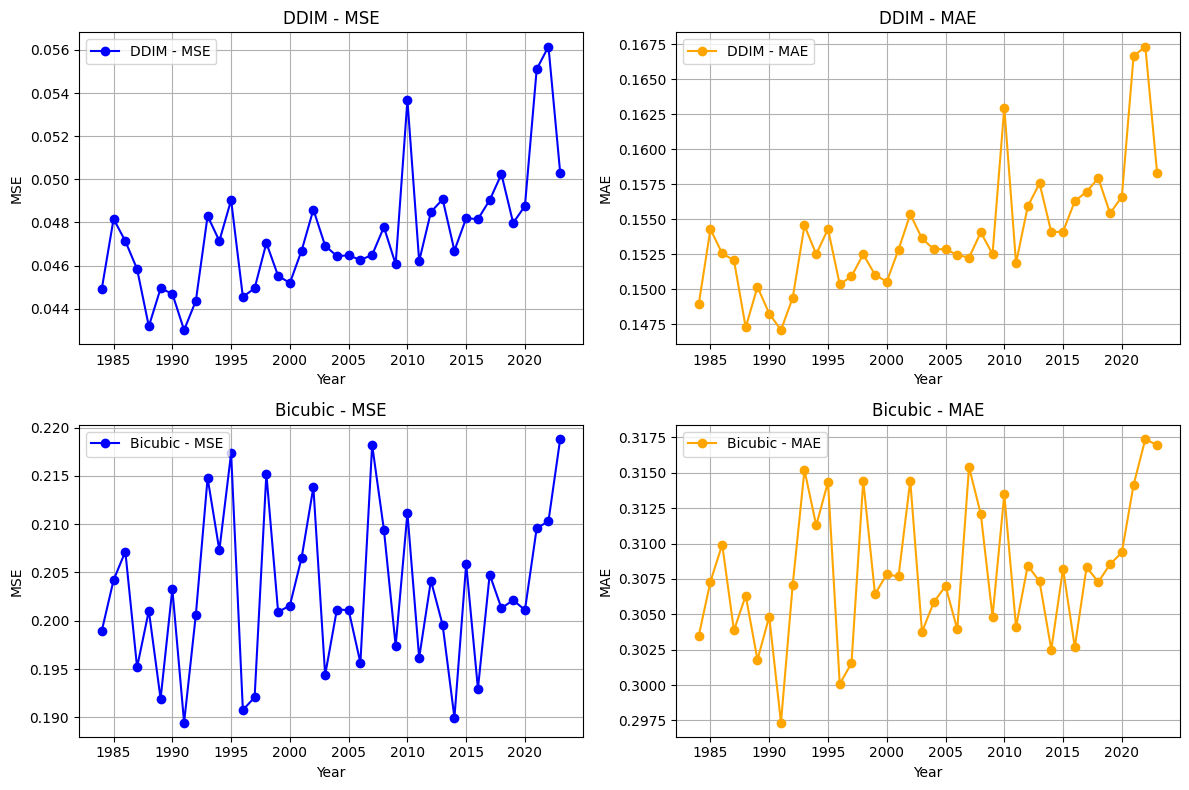

In [25]:
mses2, maes2, mse_skill_scores2, mae_skill_scores2 = get_metrics_over_time(years2)
plot_metrics_over_time(years2, mses2, maes2)